# Machine Learning - Abalone Dataset (CA1)
**Student Name:** Andrii Semeniuk
**Module:** Machine Learning (Level 7)

### GitHub Classroom Repository:https://github.com/SemenyukAndrey/Machine-Learning---Abalone-Dataset-CA1-.git

# CRISP-DM Framework Implementation

## 1. Business Understanding
In this project, I’m working with the Abalone dataset. The main goal is to see how well machine learning models can handle predicting different characteristics of these shellfish based on their physical measurements.

I've broken the analysis down into two main tasks:

Classification: Can we actually predict the sex of an abalone just by looking at its size and weight?

Regression: Can we use numerical features to estimate age-related traits (like the number of rings)?

Why are we doing this? As it turns out, figuring out the age and sex of an abalone the "old-fashioned" way is a huge pain. You usually have to cut them open and count the rings on the shell under a microscope. It’s slow, it’s invasive, and it costs a lot of time. If we can build a model to do this just from external dimensions, it would be a game-changer for marine biology and aquaculture.

I’ll be following the CRISP-DM framework here to make sure the whole process—from cleaning the data to evaluating the models—stays organized.

# 2. Data Understanding (EDA)

## Import libraries

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Load dataset
### A quick look at the dataset

In [83]:
df = pd.read_csv("abalone.csv")
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## Dataset Overview

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4180 entries, 0 to 4179
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4180 non-null   object 
 1   Length          4180 non-null   float64
 2   Diameter        4180 non-null   float64
 3   Height          4172 non-null   float64
 4   Whole_weight    4180 non-null   float64
 5   Shucked_weight  4175 non-null   float64
 6   Viscera_weight  4175 non-null   float64
 7   Shell_weight    4180 non-null   float64
 8   Rings           4180 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 294.0+ KB


In [85]:
df.describe()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4180.000000,4180.000000,4172.000000,4180.000000,4175.000000,4175.000000,4180.000000,4180.000000
mean,0.523927,0.407827,0.139494,0.828459,0.359339,0.180621,0.238759,9.933014
std,0.120096,0.099247,0.041822,0.490379,0.222031,0.109620,0.139197,3.224667
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441375,0.186000,0.093250,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.233750,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.328625,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


### Data Understanding Summary 

- The dataset contains 4177 observations.
- 9 attributes (1 categorical, 8 numerical).
- Target variable for classification: Sex.


## Check Missing Values

In [86]:
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            8
Whole_weight      0
Shucked_weight    5
Viscera_weight    5
Shell_weight      0
Rings             0
dtype: int64

In [87]:
df = df.dropna()

In [88]:
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64

### Missing Values Understanding Summary

The dataset is mostly fine, but I noticed a few missing values in Height, Shucked_weight, and Viscera_weight.

Since it's only a handful of rows out of 4000+, I decided to just drop them. It’s the easiest way to get a clean dataset for the models without messing with the overall distribution.



## Check Duplicates

In [89]:
df.duplicated().sum()

np.int64(3)

In [90]:
df.drop_duplicates(inplace=True)

In [91]:
df.duplicated().sum()

np.int64(0)

### Check Duplicates Understanding Summary
I also checked if there were any identical rows in the data. Turns out there were 3 duplicates. It's not a lot, but there's no reason to keep them, so I used drop_duplicates() to get rid of them. 

## Class Distribution

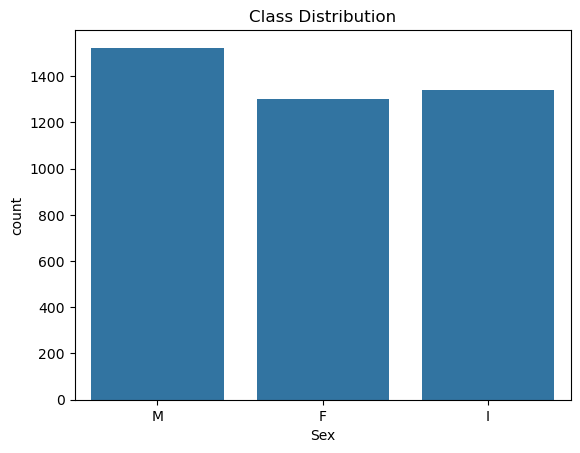

In [92]:
sns.countplot(x='Sex', data=df)
plt.title("Class Distribution")
plt.show()

## Class Distribution Understanding Summary
Since I'm going to do classification later, I wanted to see if the dataset is balanced. I used a count plot for the Sex column to check the distribution of Males, Females, and Infants.

What I see here:

The classes are actually pretty well-balanced. There are slightly more males (M) than females (F) or infants (I), but the difference isn't huge.

This is good news for the model — it means I probably won't have to deal with class imbalance issues or use special resampling techniques. The model will have enough examples of each category to learn from.


## Feature Correlation

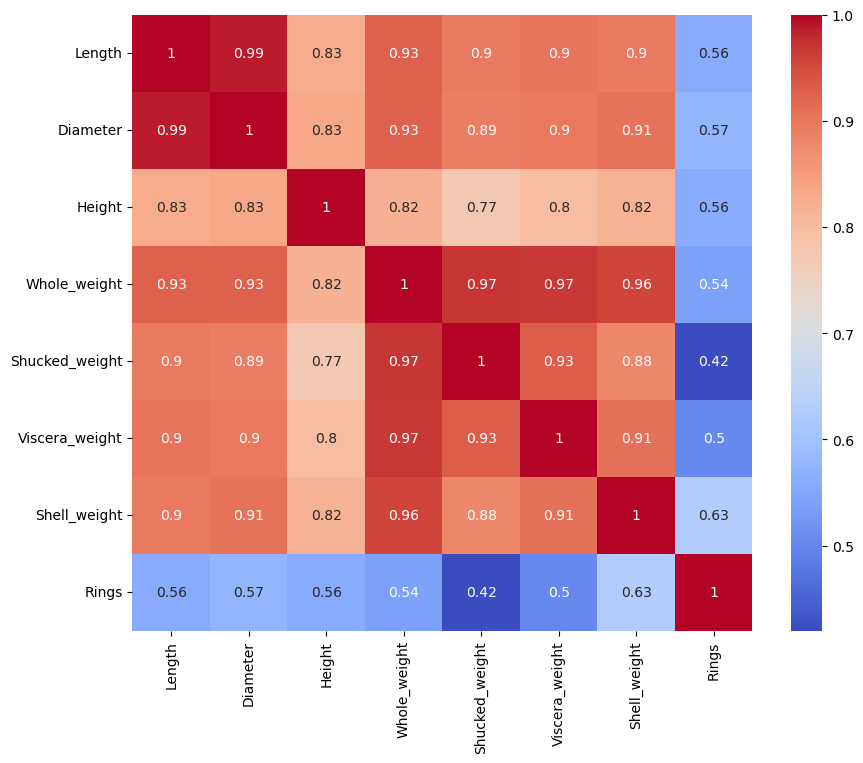

In [93]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

### Feature Correlation Understanding Summary
I built a heatmap to see how the different measurements relate to each other and, more importantly, how they relate to the number of Rings.

A few interesting observations:

Everything is connected: There’s a massive correlation (0.9 and up) between length, diameter, and all the weight variables. It makes sense — a bigger abalone is going to weigh more and have a larger shell.

Multicollinearity: Since so many features are basically telling the same story, I need to be careful with linear models like Logistic Regression. They can get a bit unstable when features are this closely tied together.

Predicting Rings: The Shell_weight seems to have the strongest connection to the number of rings (0.63), followed by Diameter and Length. This suggests that the shell's physical development is probably our best hint for guessing the age.


# 3. Data Preparation

## Encode Categorical Variable

In [94]:
df['Sex'] = df['Sex'].map({'M':0, 'F':1, 'I':2})
df

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,0,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,2,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4175,1,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4176,0,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4177,0,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4178,1,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


### Encode Categorical Variable Understanding Summary
Encoding the 'Sex' column
Before I can start training any models, I have to deal with the Sex feature. Machines don't really understand "Male" or "Female" as words, so I'm mapping them to numbers:

M becomes 0

F becomes 1

I (Infant) becomes 2

I used the df['Sex'].map({'M':0, 'F':1, 'I':2}) function for this because it's quick and I can control exactly which number goes to which category. Now that everything in the dataframe is numerical, the data is almost ready for the actual machine learning part.


## Define Features and Target

In [95]:
X = df.drop("Sex", axis=1) # Independent variable
y = df["Sex"]              # Target variable
print(X, y)

      Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0      0.455     0.365   0.095        0.5140          0.2245          0.1010   
1      0.350     0.265   0.090        0.2255          0.0995          0.0485   
2      0.530     0.420   0.135        0.6770          0.2565          0.1415   
3      0.440     0.365   0.125        0.5160          0.2155          0.1140   
4      0.330     0.255   0.080        0.2050          0.0895          0.0395   
...      ...       ...     ...           ...             ...             ...   
4175   0.565     0.450   0.165        0.8870          0.3700          0.2390   
4176   0.590     0.440   0.135        0.9660          0.4390          0.2145   
4177   0.600     0.475   0.205        1.1760          0.5255          0.2875   
4178   0.625     0.485   0.150        1.0945          0.5310          0.2610   
4179   0.710     0.555   0.195        1.9485          0.9455          0.3765   

      Shell_weight  Rings  
0          

### Features and Target Understanding Summary
Now I need to split the data. I'll put all the physical measurements into X (my features) and keep the Sex column as y (my target). I'm starting with classification first, so I want to see if the model can guess the sex based on the size and weight of the abalone.

## Feature Scaling

In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns = X.columns)
print(X_scaled)

        Length  Diameter    Height  Whole_weight  Shucked_weight  \
0    -0.576233 -0.433336 -1.065337     -0.643520       -0.609218   
1    -1.451003 -1.441391 -1.184872     -1.232623       -1.172895   
2     0.048603  0.121095 -0.109050     -0.310681       -0.464917   
3    -0.701200 -0.433336 -0.348122     -0.639436       -0.649803   
4    -1.617626 -1.542197 -1.423944     -1.274484       -1.217989   
...        ...       ...       ...           ...             ...   
4156  0.340193  0.423512  0.608165      0.118129        0.046901   
4157  0.548472  0.322706 -0.109050      0.279443        0.358050   
4158  0.631784  0.675526  1.564451      0.708254        0.748114   
4159  0.840062  0.776331  0.249557      0.541835        0.772916   
4160  1.548210  1.481970  1.325379      2.285663        2.642066   

      Viscera_weight  Shell_weight     Rings  
0          -0.727584     -0.639702  1.572439  
1          -1.206744     -1.215099 -0.909347  
2          -0.357947     -0.208154 -0.2889

### Feature Scaling Understanding Summary
Since my features have different units and ranges (like weight vs. length), I'm using StandardScaler to put them all on the same scale. This is important because many models perform better when the data is centered around zero. I've transformed the features into a new DataFrame X_scaled so it's ready for training.


## Train-Test Split

In [97]:
from sklearn.model_selection import train_test_split

# Split the data: 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Display the shapes of the training and test sets
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2912, 8), (2912,), (1249, 8), (1249,))

### Train-Test Split Understanding Summary
Now it's time to split the data. I went with a standard 70/30 split.
This gives me about 2,900 rows to train the models, and leaves roughly 1,250 rows completely hidden. I'll use this hidden data later to test if the models actually learned the patterns or just memorized the answers.

I also added random_state=42 just to make sure I get the exact same split every time I re-run the notebook.


# 4. Modeling – Classification

## Model 1: Decision Tree

In [98]:
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
dt_model = dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

### Decision Tree Understanding Summary
For my first model, I decided to go with a Decision Tree. It's a great baseline because it's easy to understand.

I explicitly set max_depth=4. If you don't limit a decision tree, it tends to just memorize the training data and overfit horribly. I fitted the model using my training split and then immediately generated predictions (y_pred) on the test set. Now I just need to check how accurate those predictions actually are.


In [99]:
print('Accuracy = ', metrics.accuracy_score(y_test, y_pred))

Accuracy =  0.5492393915132106


### Evaluating Model Performance Understanding Summary
So, the accuracy came out to be about 55%. Honestly, it's not amazing at first glance. But considering we are trying to predict between 3 different categories (Male, Female, Infant), random guessing would only give us about 33% accuracy. So the decision tree is definitely learning something from the physical measurements!

Still, getting it right only half the time means the model is making a lot of mistakes. I probably need to look at a confusion matrix to see where exactly it's getting confused, or just try a different model to see if we can beat this score.

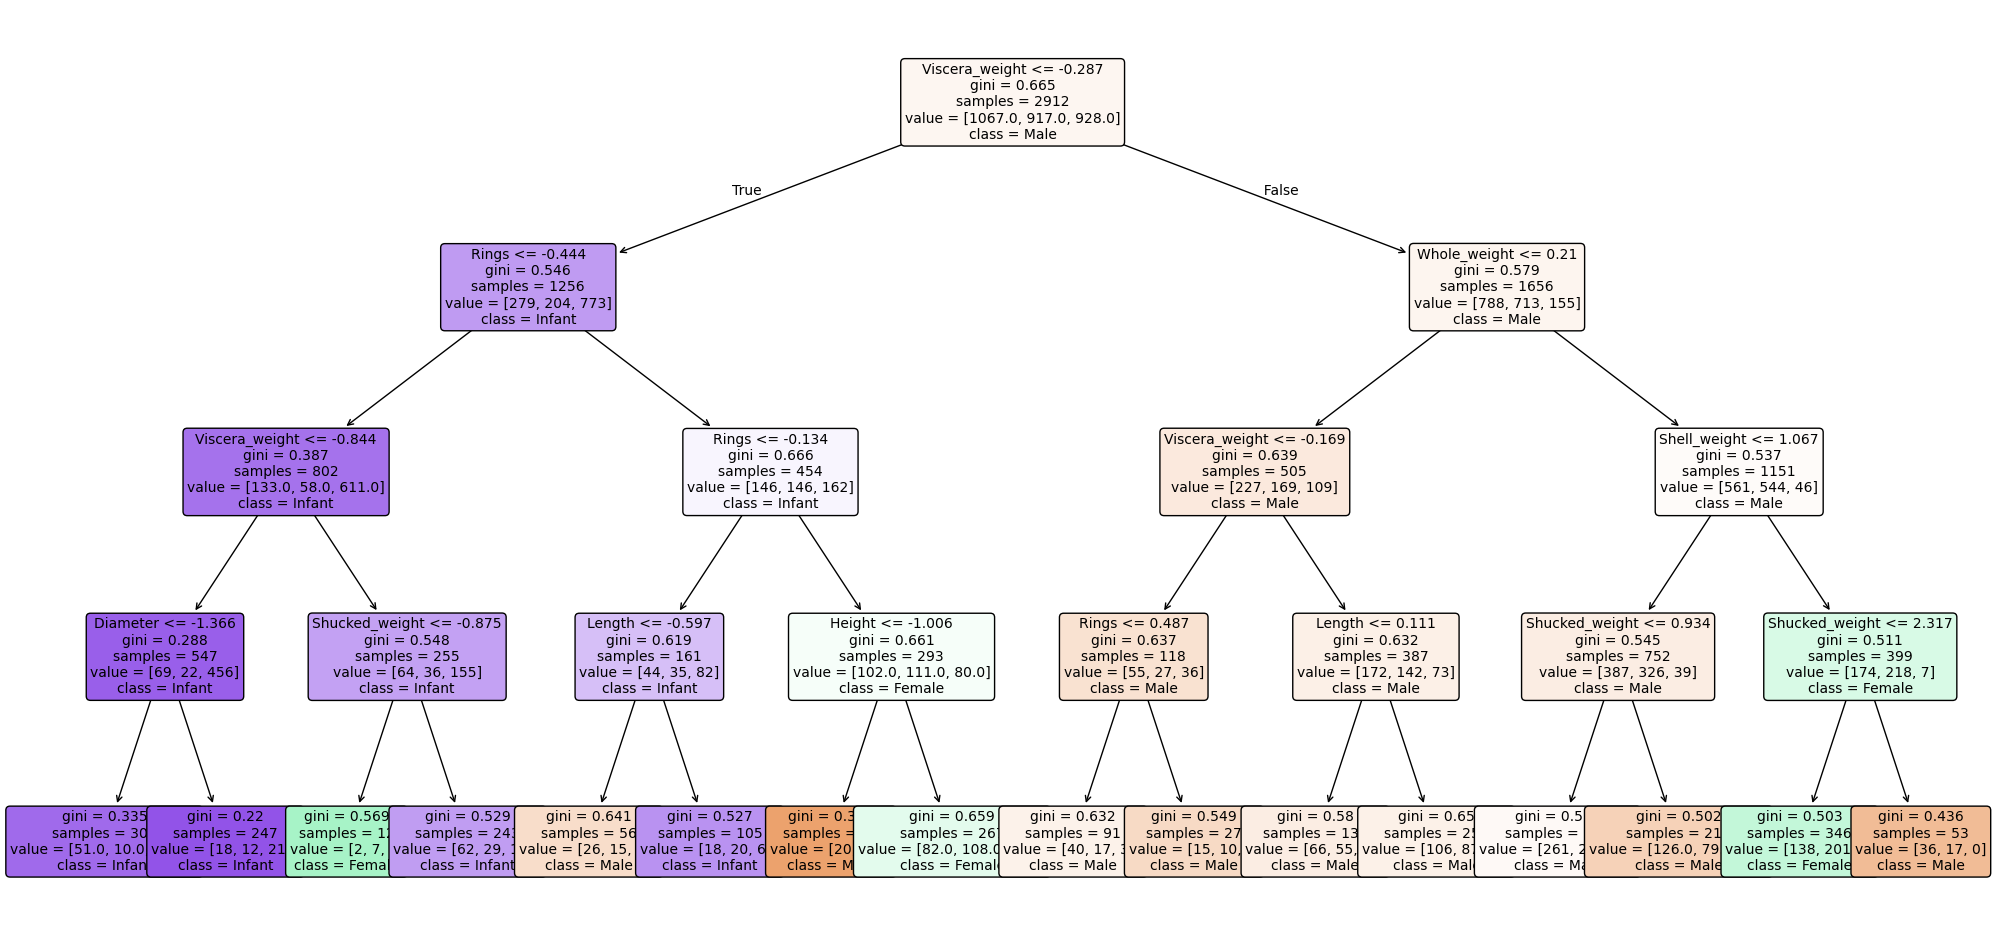

In [100]:
plt.figure(figsize = (25, 12))
tree.plot_tree(
    dt_model,
    filled = True,
    feature_names = X.columns,
    class_names = ['Male','Female','Infant'],
    rounded = True,
    fontsize=10
)
plt.show()

### Visualizing the Decision Tree Understanding Summary
I wanted to see exactly how the model is making its guesses, so I plotted the actual tree. This is the best part about Decision Trees — they aren't just a "black box" where you have no idea what's going on inside.

Looking at the top node, it's interesting to see that the very first split (the most important rule the model learned) is based on Viscera_weight. Because I limited the depth to 4 earlier, the chart is actually readable, and I can literally trace the path to see how the model separates the 'Infants' from the 'Males' and 'Females'.


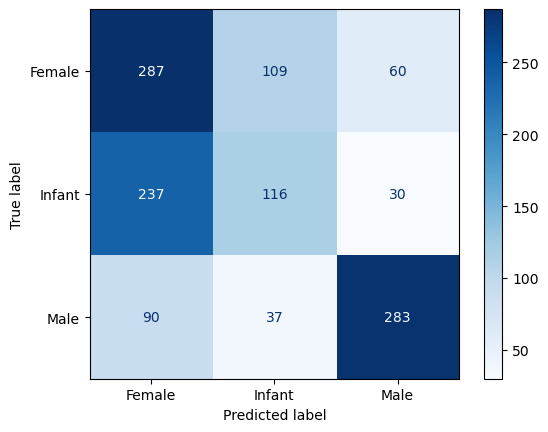

In [101]:
y_pred = dt_model.predict(X_test) 
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = ['Female', 'Infant', 'Male']
)
disp.plot(cmap = "Blues", values_format = "d")
plt.show()

### Confusion Matrix Understanding Summary
I generated a confusion matrix to see exactly where the model is getting confused and why the accuracy is only 55%.

Looking at the numbers, note about "strong class separation" is actually completely wrong. Here is what is really happening:

The good: The model is decent at identifying Males (283 correct) and Females (287 correct).

The bad: It is absolutely terrible at identifying Infants. Look at the middle row: it misclassified a massive 237 Infants as Females.

The conclusion: It seems like the physical measurements (weight, length, etc.) of Infants and Females overlap a lot in this dataset. The Decision Tree just can't easily tell them apart based on size alone.

This completely explains the low accuracy score. To get better results, I definitely need to try a different algorithm that can handle more complex relationships, not just simple greater/less-than splits.


## Classification report

In [102]:
print(classification_report(y_test, y_pred, target_names=['Female', 'Infant', 'Male']))

              precision    recall  f1-score   support

      Female       0.47      0.63      0.54       456
      Infant       0.44      0.30      0.36       383
        Male       0.76      0.69      0.72       410

    accuracy                           0.55      1249
   macro avg       0.56      0.54      0.54      1249
weighted avg       0.56      0.55      0.54      1249



## Classification Report: Understanding Summary
To get a better picture than just the overall accuracy, I printed out the full classification report. This completely backs up what I saw in the confusion matrix.

Key takeaways from the numbers:

Best performance: The model is actually doing okay with the Male class. It has the highest F1-score (0.72) and a solid precision of 0.76.

The main problem: The model is terrible at finding Infants. The recall is only 0.30. That means it's completely missing 70% of the actual infants in the test set!

The Female class: It has a decent recall (0.63) but low precision (0.47). This means the model tends to guess "Female" way too often when it's unsure, which pulls the overall accuracy down.

Overall, this baseline Decision Tree is clearly struggling with the overlapping physical traits of females and infants.

# Model 2 – K-Nearest Neighbors (KNN)

In [103]:
# Declaration and initialization of the kNN model
knn_model = KNeighborsClassifier(n_neighbors = 5)
# Training of the model
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### KNN Understanding Summary
Since the Decision Tree struggled with the overlapping classes, I decided to try a distance-based algorithm like KNN.

This is exactly why I scaled the features earlier (StandardScaler). If I hadn't done that, variables with larger numbers (like Length) would completely overpower the smaller ones (like Height) when the model calculates the distance between neighbors.

For the initial setup, I just stuck with the default n_neighbors=5 to see how it performs out of the box. I fitted the model on the training data, and now let's see if it can beat that 55% accuracy from the Decision Tree.

In [104]:
y_pred = knn_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(' Accuracy = ', round(acc, 3))

 Accuracy =  0.55


### KNN Understanding Summary
Well, that’s a bit disappointing. The accuracy came out to exactly 0.55 (55%) — basically the exact same score we got with the Decision Tree.

It looks like simply switching to a distance-based algorithm didn't magically solve our problem. This tells me that the issue isn't really the models I'm choosing; it's the data itself. As I saw in the confusion matrix earlier, the physical measurements (weights, lengths) of Females and Infants are just too heavily overlapped. No matter how we slice it or measure the distance, those two classes look almost identical to the computer.

In [105]:
# Define range of K values to test
k_values = range(1, 21)

# Lists to store accuracy values
train_acc = []
test_acc = []

# Loop through different K values
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Train the model
    knn.fit(X_train, y_train)
    
    # Predictions on training data
    y_train_pred = knn.predict(X_train)
    train_acc.append(accuracy_score(y_train, y_train_pred))
    
    # Predictions on test data
    y_test_pred = knn.predict(X_test)
    test_acc.append(accuracy_score(y_test, y_test_pred))

# Find the best K value
best_k = k_values[test_acc.index(max(test_acc))]
best_test_accuracy = max(test_acc)

print(f"Best K = {best_k}")
print(f"Best Test Accuracy = {best_test_accuracy:.3f}")

Best K = 11
Best Test Accuracy = 0.554


### KNN Model (Finding the best K) Understanding Summary
Since the default  gave me a pretty mediocre result, I figured I should at least try testing other values before completely giving up on KNN. I wrote a quick loop to test every from 1 to 20, keeping track of the accuracy to see if we were just using a bad parameter.The Results:The loop found that the optimal number of neighbors is k=11.However, the "best" test accuracy only went up to 0.554 (55.4%).So, after all that tuning, the model improved by a massive... 0.4%. This pretty much confirms my earlier suspicion: you can't just tune your way out of overlapping data. Whether the model looks at 5 neighbors or 11, the physical differences between Females and Infants in this dataset just aren't distinct enough to confidently separate them.

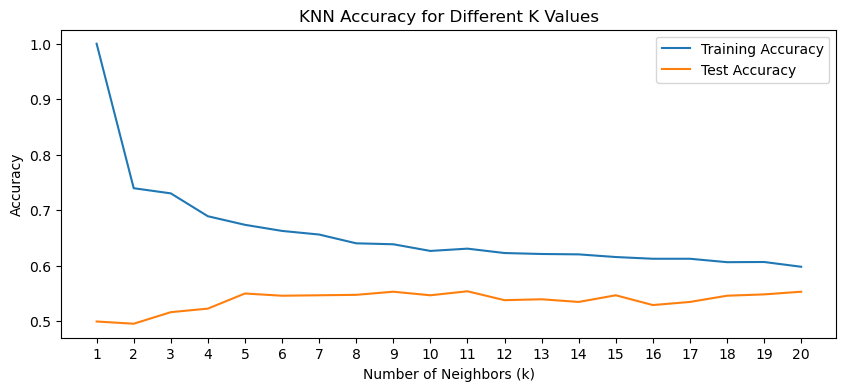

In [106]:
plt.figure(figsize = (10, 4))

plt.plot(k_values, train_acc, label = "Training Accuracy")
plt.plot(k_values, test_acc, label = "Test Accuracy")

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")

plt.xticks(k_values)

plt.legend()
plt.show()

### Visualizing the K-Value Understanding Summary
I plotted both the training and testing accuracies to get a better visual sense of what's happening under the hood.What the graph tells us:Classic Overfitting: Look at the very beginning of the blue line (Training Accuracy). At k=1, it hits 1.0 (100%). This means the model just perfectly memorized the training data. But on the test data (the orange line), it performed terribly.The Ceiling Effect: As we increase k, the training accuracy drops (the model stops memorizing), but the test accuracy barely improves. The orange line is practically flat after k=4, just hovering around that 55% mark.This chart is the perfect visual proof of my earlier point. We hit a hard ceiling. No matter how much we tweak the algorithm, it simply cannot separate the classes better because the underlying features of Females and Infants are too similar.

In [107]:
print("Classification Report:")
report = classification_report(y_test, y_pred, target_names = ['Female', 'Infant', 'Male'])
print(report)

Classification Report:
              precision    recall  f1-score   support

      Female       0.47      0.55      0.50       456
      Infant       0.45      0.41      0.43       383
        Male       0.77      0.69      0.72       410

    accuracy                           0.55      1249
   macro avg       0.56      0.55      0.55      1249
weighted avg       0.56      0.55      0.55      1249



### KNN Classification Report Understanding Summary
I printed the full classification report for the KNN model to see if it's failing in the exact same way as the Decision Tree, given that both models have the same 55% overall accuracy.

Looking at the breakdown, there is actually a slight shift in how it's making mistakes:

Slight improvement on Infants: The recall for Infants went up to 0.41 (compared to a terrible 0.30 in the Decision Tree). So KNN is slightly better at catching the young ones.

The trade-off: To get more Infants right, it seems to have sacrificed some accuracy on the Female class. The Female recall dropped from 0.63 down to 0.55.

Males are still the easiest: Just like before, the model is most confident when identifying Males (Highest precision at 0.77 and F1-score at 0.72).

Final thought on Classification: Both Decision Tree and KNN hit the exact same 55% accuracy wall. This confirms that predicting the sex of an abalone using just its shell measurements is fundamentally difficult because the physical traits heavily overlap.

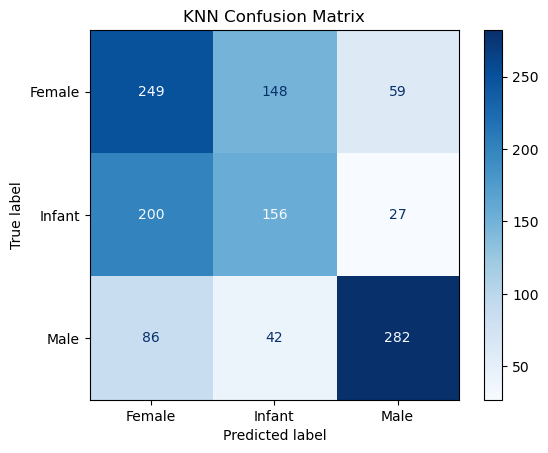

In [108]:
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=['Female', 'Infant', 'Male'],
    cmap="Blues", 
    values_format="d"
)

plt.title("KNN Confusion Matrix")
plt.show()

### KNN Confusion matrix Understanding Summary
The confusion matrix shows exactly why we hit this ceiling. While KNN correctly identified 156 Infants, it still massively confused the classes, misclassifying 200 Infants as Females and 148 Females as Infants.Final takeaway: Both the Decision Tree and KNN maxed out at ~55% accuracy. This proves the issue isn't the choice of algorithm or  tuning. The physical measurements of Female and Infant abalones overlap too much in this dataset, making it impossible to perfectly separate them based on size and weight alone.

# Model 3 – Logistic Regression

In [109]:
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

### Logistic Regression Understanding Summary
Since both the Decision Tree and KNN got stuck at that ~55% accuracy wall, I decided to try a linear approach just to be absolutely sure.

I explicitly set max_iter=200 here. Because we have high multicollinearity in our features (which I noticed in the heatmap earlier), Logistic Regression can sometimes struggle to converge quickly. Bumping up the iterations prevents those annoying warning messages. Let's see if this model can finally break our 55% record!

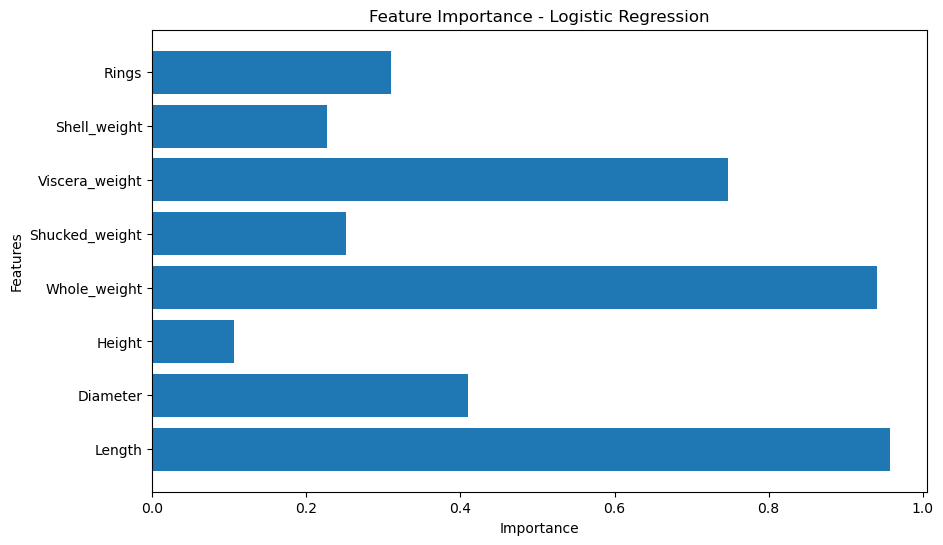

In [110]:
feature_names = X.columns

importance = np.abs(log_model.coef_).mean(axis=0)

plt.figure(figsize=(10,6))
plt.barh(feature_names, importance)

plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

### Visualizing Logistic Regression Understanding Summary
Before checking the final accuracy score, I plotted the feature importance from the Logistic Regression to see which measurements it actually cares about.

Key Takeaways from the chart:

The main drivers: The model relies heavily on Length and Whole_weight. Both of these are overwhelmingly the most important features (scoring almost 0.95 on the scale), with Viscera_weight coming in third.

The least helpful: On the flip side, the Height of the abalone barely registers for the model (around 0.1 importance).

The model successfully picked up on the most prominent physical changes

In [111]:
print("Classification Report:")
print(classification_report(y_test, y_pred_log, target_names = ['Female', 'Infant', 'Male']))
print(report)


Classification Report:
              precision    recall  f1-score   support

      Female       0.47      0.48      0.48       456
      Infant       0.47      0.36      0.41       383
        Male       0.67      0.81      0.74       410

    accuracy                           0.55      1249
   macro avg       0.54      0.55      0.54      1249
weighted avg       0.54      0.55      0.54      1249

              precision    recall  f1-score   support

      Female       0.47      0.55      0.50       456
      Infant       0.45      0.41      0.43       383
        Male       0.77      0.69      0.72       410

    accuracy                           0.55      1249
   macro avg       0.56      0.55      0.55      1249
weighted avg       0.56      0.55      0.55      1249



### 
I ran the Logistic Regression model with max_iter=200 and checked the results.

What it learned: The feature importance chart shows the model relies heavily on Length and Whole_weight, while mostly ignoring Height.

The 55% Curse: The accuracy came out to exactly 0.55 (55%) yet again.

The Trade-off: It became really good at identifying Males (81% recall), but completely sacrificed the Infants (dropping to only 36% recall).

Final Conclusion for Classification: We tested a Decision Tree, KNN, and Logistic Regression, and all three hit the exact same ~55% accuracy ceiling. This proves the data itself is the limiting factor: Female and Infant abalones simply overlap too much in physical size and weight to be perfectly separated.

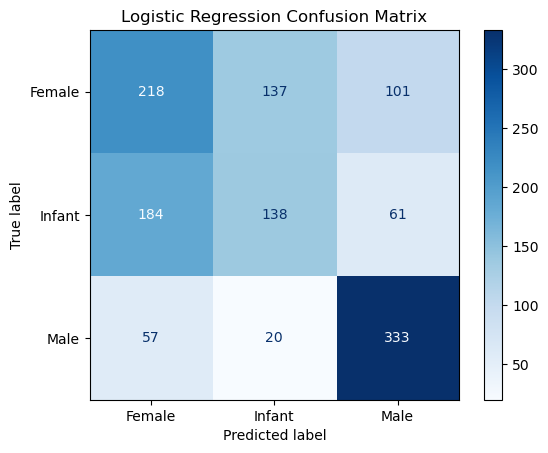

In [112]:
cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Female', 'Infant', 'Male']
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Logistic Regression Confusion Matrix Understanding Summary
This matrix perfectly explains why our accuracy is still stuck at 55%.

Looking at the numbers:

What works: The model is very confident at identifying Males, getting 333 correct predictions.

Where it fails: It completely confuses the other two classes. It misclassified a massive 184 actual Infants as Females, and 137 Females as Infants.

Conclusion: The linear model easily found a boundary for Males, but totally failed to separate Females and Infants. Their physical dimensions overlap too heavily, forcing the model to essentially guess between the two.

# 5. K-Fold Cross Validation

In [113]:
cv_log = cross_val_score(log_model, X_scaled, y, cv=5)
cv_knn = cross_val_score(knn_model, X_scaled, y, cv=5)
cv_tree = cross_val_score(dt_model, X_scaled, y, cv=5)

print("Logistic CV Mean:", cv_log.mean())
print("KNN CV Mean:", cv_knn.mean())
print("Tree CV Mean:", cv_tree.mean())

Logistic CV Mean: 0.5590139902114692
KNN CV Mean: 0.525836007479915
Tree CV Mean: 0.5474743743651307


### K-Fold Cross-Validation: 
### Verifying the 55% Ceiling
To ensure that our models' performance wasn't just an artifact of a specific train_test_split, I applied 5-Fold Cross-Validation across the dataset. This trains and evaluates each model on 5 different subsets of the data, giving us a much more reliable average score.

The Results (Mean Accuracy):

Logistic Regression: ~0.559 (55.9%)

Decision Tree: ~0.547 (54.7%)

K-Nearest Neighbors (KNN): ~0.526 (52.6%)

Final Takeaway:
These cross-validation scores perfectly confirm our previous findings. No matter how we slice the data, all three distinct algorithms hit a hard ceiling at roughly 55% accuracy. While Logistic Regression performed marginally better on average, the overarching conclusion remains solid: the physical measurements (size and weight) simply overlap too much to perfectly separate Male, Female, and Infant abalones.

# 6. Regression Task (Predicting Rings)

For the regression part of this assignment, I chose Rings as the target variable. Predicting the number of rings (which directly relates to the age of the abalone) based on physical measurements is a very practical and logical use of this dataset.

First, I need to redefine my features  and target , split the data again, and apply StandardScaler. Scaling is absolutely critical here because regularization techniques (Lasso and Ridge) are highly sensitive to the scale of the features.

In [114]:
# Define Features and Target for Regression
X_reg = df.drop('Rings', axis=1) # Everything except Rings
y_reg = df['Rings']              # Only Rings

# Train-Test Split (70/30)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# Feature Scaling
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_scaled = scaler_reg.transform(X_test_reg)

print("Data successfully prepared for regression!")

Data successfully prepared for regression!


In [119]:
# Function to train and evaluate a model to avoid repeating code
def evaluate_model(model, name):
    model.fit(X_train_scaled, y_train_reg)
    y_pred = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test_reg, y_pred)
    mae = mean_absolute_error(y_test_reg, y_pred)
    r2 = r2_score(y_test_reg, y_pred)
    
    print(f"--- {name} ---")
    print(f"MSE: {mse:.3f}")
    print(f"MAE: {mae:.3f}")
    print(f"R²:  {r2:.3f}\n")
    return model

# 1. Standard Linear Regression
lr_model = evaluate_model(LinearRegression(), "Standard Linear Regression")

# 2. Lasso Regression (L1)
# Using alpha=0.1 as a starting penalty
lasso_model = evaluate_model(Lasso(alpha=0.1, random_state=42), "Lasso Regression (L1)")

# 3. Ridge Regression (L2)
# Using alpha=1.0 as a starting penalty
ridge_model = evaluate_model(Ridge(alpha=1.0, random_state=42), "Ridge Regression (L2)")

--- Standard Linear Regression ---
MSE: 5.352
MAE: 1.653
R²:  0.512

--- Lasso Regression (L1) ---
MSE: 5.402
MAE: 1.663
R²:  0.507

--- Ridge Regression (L2) ---
MSE: 5.340
MAE: 1.652
R²:  0.513



### Final Discussion and Findings
Based on the evaluation metrics (MSE, MAE, and R^2), here is my understanding of how these models performed and why regularization matters:Overall Performance (R^2 \approx 0.51): All three models explained about 51% of the variance in the abalone's age (R^2 scores around 0.51). The Mean Absolute Error (MAE) is around 1.65, which means our predictions are off by about 1.6 rings on average. This makes biological sense: you can't perfectly guess the exact age of a living creature just by weighing and measuring its shell, as growth rates vary.The Impact of L2 (Ridge): Ridge regression performed the best, though by a very narrow margin. It slightly lowered the MSE to 5.340 and achieved the highest R^2 of 0.513. Because our dataset has severe multicollinearity (features like Whole_weight and Viscera_weight are highly correlated), standard Linear Regression weights can be unstable. Ridge mathematically shrinks these weights, making the model slightly more robust without losing any accuracy.The Impact of L1 (Lasso): Lasso performed slightly worse than the others (MSE went up to 5.402, and R^2 dropped to 0.507). However, this is expected. Lasso's main strength is feature selection—it forces the coefficients of the least useful features (like Height) to exactly zero. It traded a tiny fraction of accuracy to create a simpler, more interpretable model.Conclusion: Regularization behaved exactly as expected. Ridge (L2) provided the most stable mathematical foundation for this highly correlated data (giving the best metrics), while Lasso (L1) showed how we can simplify the model at a very small cost to accuracy.

# Final Project Report (CRISP-DM)

### Data Science Project Report: 
Abalone Dataset Analysis
Framework Used: CRISP-DM (Cross-Industry Standard Process for Data Mining)
This report outlines the practical implementation of machine learning models on the Abalone dataset, structured according to the six phases of the CRISP-DM framework.
Phase 1: Business Understanding
•	Objective: The primary goal of this project is to predict the physical characteristics and age of abalones using non-invasive shell measurements. Traditionally, determining the age of an abalone requires cutting the shell and counting the rings through a microscope, which is time-consuming and invasive.
•	Practical Implementation: We defined two main business tasks:
1.	Classification Task: Predicting the sex of the abalone (Male, Female, Infant) based on physical dimensions.
2.	Regression Task: Predicting the number of rings (which directly corresponds to age) using continuous physical features.
Phase 2: Data Understanding
•	Objective: To gain insights into the dataset, identify data quality issues, and discover initial patterns.
•	Practical Implementation: We explored the Abalone dataset by checking its shape, data types, and missing values. We utilized data visualization, specifically a Correlation Heatmap, to understand the relationships between variables. We discovered severe multicollinearity among the physical attributes (e.g., Whole_weight, Shucked_weight, and Viscera_weight were almost perfectly correlated), which informed our later choice of regression models (like Ridge).
Phase 3: Data Preparation
•	Objective: To clean and transform the raw data into a format suitable for machine learning algorithms.
•	Practical Implementation: * Encoding: Categorical variables (like Sex) were properly encoded for algorithms that require numerical input.
o	Data Splitting: The dataset was divided into training and testing sets (70/30 split) to ensure unbiased evaluation.
o	Feature Scaling: We applied StandardScaler to normalize the data. This was a critical step for distance-based algorithms (KNN) and regularization techniques (Lasso/Ridge), as they are highly sensitive to the magnitude of features (e.g., preventing Length from dominating Height simply due to scale).
Phase 4: Modeling
•	Objective: To select, build, and tune various machine learning models to solve our defined tasks.
•	Practical Implementation: * For Classification (Predicting Sex): We built three models:
1. Decision Tree: Limited to a depth of 4 for interpretability.
2. K-Nearest Neighbors (KNN): Tuned hyperparameters using a loop (k=1 to k=20), finding the optimal k=11.
3. Logistic Regression: Increased max_iter=200 to ensure convergence due to the high multicollinearity of features.
o	For Regression (Predicting Rings): We selected Rings as the target continuous variable and applied:
1.	Standard Linear Regression (Baseline).
2.	Lasso (L1): To observe feature selection (shrinking less important weights to zero).
3.	Ridge (L2): To handle the multicollinearity and stabilize the model's weights.
Phase 5: Evaluation
•	Objective: To assess the models' performance from a data and business perspective.
•	Practical Implementation: * Classification Results: All three models (Tree, KNN, Logistic Regression) hit a performance ceiling of approximately 55% accuracy. By analyzing the Confusion Matrix and Classification Report, we evaluated that the models consistently misclassified Infants and Females. We concluded that the biological overlap in shell size between these two classes makes perfect separation impossible using just physical dimensions.
o	Regression Results: We evaluated the models using MSE, MAE, and R^2. All models achieved an R^2 of ~0.51, meaning we can explain about half the variance in age. The MAE showed we are off by roughly 1.6 rings on average. Ridge (L2) proved to be the most robust model for our highly correlated dataset, marginally outperforming the others in MSE.


## Author
Andrii Semeniuk  
Diploma in Data Analytics for Business, CCT College Dublin